In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Handling Numerical Values

In [26]:
df = pd.read_csv('data_science_job.csv', index_col=0)

In [27]:
df = df.select_dtypes(exclude='object')

In [28]:
df

,city_development_index,experience,training_hours,target
enrollee_id,,,,
8949,0.920,20.0,36.0,1.0
29725,0.776,15.0,47.0,0.0
11561,0.624,5.0,83.0,0.0
33241,0.789,0.0,52.0,1.0
666,0.767,20.0,8.0,0.0
...,...,...,...,...
7386,0.878,14.0,42.0,1.0
31398,0.920,14.0,52.0,1.0
24576,0.920,20.0,44.0,0.0


In [29]:
df.shape

(19158, 4)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19158 entries, 8949 to 23834
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  18679 non-null  float64
 1   experience              19093 non-null  float64
 2   training_hours          18392 non-null  float64
 3   target                  19158 non-null  float64
dtypes: float64(4)
memory usage: 748.4 KB


In [31]:
df.describe()

,city_development_index,experience,training_hours,target
count,18679.000000,19093.000000,18392.000000,19158.000000
mean,0.828951,9.928036,65.185787,0.249348
std,0.123334,6.505268,59.885626,0.432647
min,0.448000,0.000000,1.000000,0.000000
25%,0.740000,4.000000,23.000000,0.000000
50%,0.903000,9.000000,47.000000,0.000000
75%,0.920000,16.000000,88.000000,0.000000
max,0.949000,20.000000,336.000000,1.000000


In [32]:
column = (df.isnull().mean()*100)
print(column[column > 0])

city_development_index    2.500261
experience                0.339284
training_hours            3.998330
dtype: float64


In [33]:
cols = [var for var in df.columns if df[var].isnull().mean() > 0 and df[var].isnull().mean() < 0.05]
cols

['city_development_index', 'experience', 'training_hours']

In [34]:
df[cols].sample(5)

,city_development_index,experience,training_hours
enrollee_id,,,
23681,0.920,5.0,3.0
1353,0.920,4.0,150.0
1586,0.939,6.0,59.0
8047,0.855,14.0,44.0
25648,0.910,3.0,46.0


In [35]:
len(df[cols].dropna())/len(df)*100

93.25086125900407

In [36]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 4), (17865, 3))

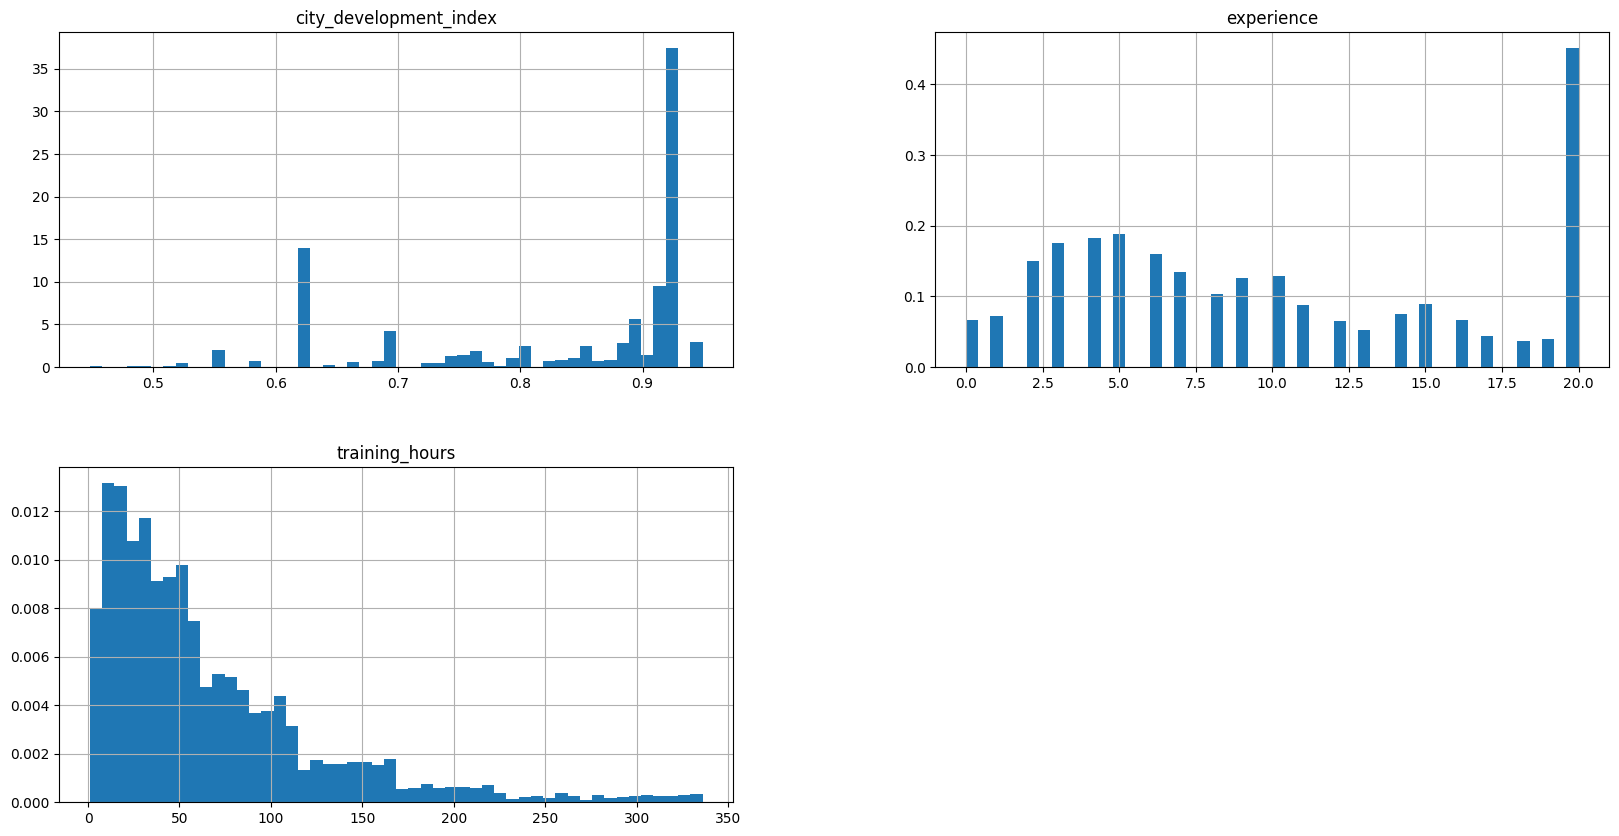

In [37]:
new_df.hist(bins=50, density=True, figsize=(20, 10))
plt.show()

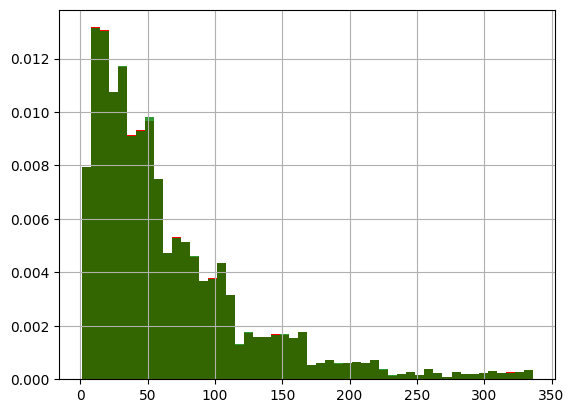

In [41]:
fig =plt.figure()
ax = fig.add_subplot(111)

df['training_hours'].hist(bins=50, density=True, ax=ax, color='red')
new_df['training_hours'].hist(bins=50, density=True, ax=ax, color='green', alpha=0.8)

plt.show()

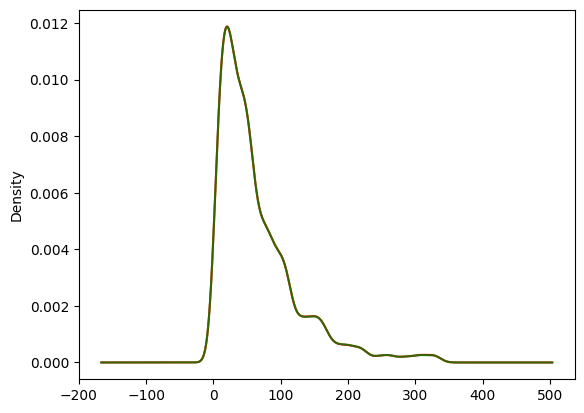

In [49]:
fig =plt.figure()
ax = fig.add_subplot(111)

df['training_hours'].plot.density(ax=ax, color='red')
new_df['training_hours'].plot.density(ax=ax, color='green', alpha=0.8)

plt.show()

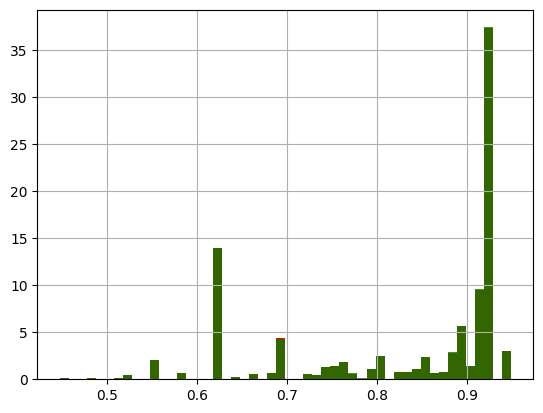

In [44]:
fig =plt.figure()
ax = fig.add_subplot(111)

df['city_development_index'].hist(bins=50, density=True, ax=ax, color='red')
new_df['city_development_index'].hist(bins=50, density=True, ax=ax, color='green', alpha=0.8)

plt.show()

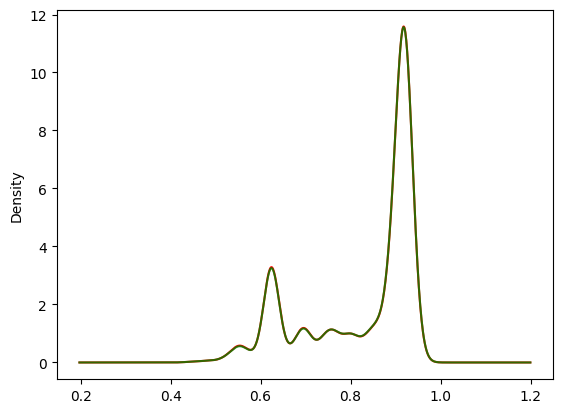

In [45]:
fig =plt.figure()
ax = fig.add_subplot(111)

df['city_development_index'].plot.density(ax=ax, color='red')
new_df['city_development_index'].plot.density(ax=ax, color='green', alpha=0.8)

plt.show()

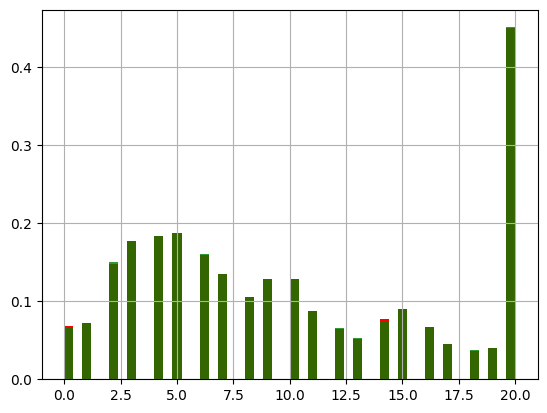

In [46]:
fig =plt.figure()
ax = fig.add_subplot(111)

df['experience'].hist(bins=50, density=True, ax=ax, color='red')
new_df['experience'].hist(bins=50, density=True, ax=ax, color='green', alpha=0.8)

plt.show()

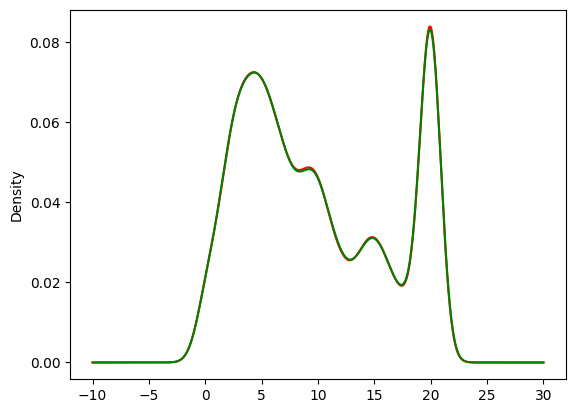

In [48]:
fig =plt.figure()
ax = fig.add_subplot(111)

df['experience'].plot.density(ax=ax, color='red')
new_df['experience'].plot.density(ax=ax, color='green', alpha=0.8)

plt.show()

# Handling Categorical Values

In [50]:
df = pd.read_csv('data_science_job.csv', index_col=0)

In [52]:
df = df.select_dtypes(include='object')

In [53]:
df

,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,company_size,company_type
enrollee_id,,,,,,,,
8949,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,NaN,NaN
29725,city_40,Male,No relevent experience,no_enrollment,Graduate,STEM,50-99,Pvt Ltd
11561,city_21,NaN,No relevent experience,Full time course,Graduate,STEM,NaN,NaN
33241,city_115,NaN,No relevent experience,NaN,Graduate,Business Degree,NaN,Pvt Ltd
666,city_162,Male,Has relevent experience,no_enrollment,Masters,STEM,50-99,Funded Startup
...,...,...,...,...,...,...,...,...
7386,city_173,Male,No relevent experience,no_enrollment,Graduate,Humanities,NaN,NaN
31398,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,NaN,NaN
24576,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,50-99,Pvt Ltd


In [54]:
df.shape

(19158, 8)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19158 entries, 8949 to 23834
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   city                 19158 non-null  object
 1   gender               14650 non-null  object
 2   relevent_experience  19158 non-null  object
 3   enrolled_university  18772 non-null  object
 4   education_level      18698 non-null  object
 5   major_discipline     16345 non-null  object
 6   company_size         13220 non-null  object
 7   company_type         13018 non-null  object
dtypes: object(8)
memory usage: 1.3+ MB


In [56]:
df.describe()

,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,company_size,company_type
count,19158,14650,19158,18772,18698,16345,13220,13018
unique,123,3,2,3,5,6,8,6
top,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,50-99,Pvt Ltd
freq,4355,13221,13792,13817,11598,14492,3083,9817


In [59]:
column = (df.isnull().mean()*100)
print(column[column > 0])

gender                 23.530640
enrolled_university     2.014824
education_level         2.401086
major_discipline       14.683161
company_size           30.994885
company_type           32.049274
dtype: float64


In [60]:
cols = [var for var in df.columns if df[var].isnull().mean() > 0 and df[var].isnull().mean() < 0.05]
cols

['enrolled_university', 'education_level']

In [61]:
df[cols].sample(5)

,enrolled_university,education_level
enrollee_id,,
26573,no_enrollment,Graduate
9191,Full time course,Masters
21389,no_enrollment,Graduate
8541,no_enrollment,Graduate
13240,Full time course,Masters


In [62]:
len(df[cols].dropna())/len(df)*100

96.10606535128929

In [63]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 8), (18412, 2))

In [64]:
new_df['education_level'].value_counts()

,count
education_level,
Graduate,11427
Masters,4308
High School,1970
Phd,408
Primary School,299


In [68]:
temp = pd.concat([df['education_level'].value_counts()/len(df), new_df['education_level'].value_counts()/len(new_df)], axis=1)
temp.columns = ['Original', 'CCA']
temp

,Original,CCA
education_level,,
Graduate,0.605387,0.620628
Masters,0.227633,0.233978
High School,0.105282,0.106995
Phd,0.021610,0.022159
Primary School,0.016077,0.016239


In [70]:
new_df['enrolled_university'].value_counts()

,count
enrolled_university,
no_enrollment,13547
Full time course,3688
Part time course,1177


In [71]:
temp = pd.concat([df['enrolled_university'].value_counts()/len(df), new_df['enrolled_university'].value_counts()/len(new_df)], axis=1)
temp.columns = ['Original', 'CCA']
temp

,Original,CCA
enrolled_university,,
no_enrollment,0.721213,0.735770
Full time course,0.196106,0.200304
Part time course,0.062533,0.063926
